# Simulator-in-the-loop training with AdaSwarm ⚙️

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AdaSwarm/AdaSwarm/blob/main/examples/simulator_in_the_loop.ipynb)

Many real objectives are computed by a **non-differentiable simulator** — a physics engine, a SPICE
circuit model, a renderer, an actuator/plant model, a market simulator. You can *run* it, but you
**cannot backprop through it**.

The usual workaround is to train against a **smooth surrogate** of the simulator — which optimises the
*wrong* (approximate) objective and leaves systematic error. Because `adaswarm.nn.SwarmLoss` only ever
*evaluates* the loss (never differentiates it), it can optimise the **true simulator directly**.

Here the "simulator" is a textbook actuator with a **deadzone, saturation, and quantization** (a
staircase response) — genuinely non-differentiable.

In [1]:
# %pip install "adaswarm[examples] @ git+https://github.com/AdaSwarm/AdaSwarm.git"  # on Colab
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import adaswarm.nn

print("adaswarm", adaswarm.__version__, "| torch", torch.__version__)

def sim_true(u):
    """Non-differentiable actuator: deadzone + saturation + quantization (staircase)."""
    v = u.clamp(-3, 3)
    v = torch.where(v.abs() < 0.5, torch.zeros_like(v), v - 0.5 * torch.sign(v))
    return torch.round(v * 4) / 4

def sim_surrogate(u):
    """Smooth differentiable approximation used by the standard baseline."""
    return 2.5 * torch.tanh(u / 2.5)

adaswarm 0.3.0 | torch 2.12.1


## 1. The simulator vs its smooth surrogate

The true actuator is a staircase with a flat deadzone; the surrogate is a smooth curve. Fitting the
surrogate necessarily misjudges the real device.

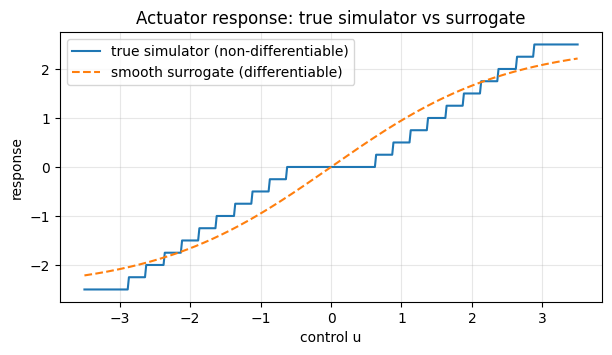

In [2]:
u = torch.linspace(-3.5, 3.5, 400)
plt.figure(figsize=(7, 3.5))
plt.plot(u, sim_true(u), label='true simulator (non-differentiable)')
plt.plot(u, sim_surrogate(u), '--', label='smooth surrogate (differentiable)')
plt.title('Actuator response: true simulator vs surrogate')
plt.xlabel('control u'); plt.ylabel('response'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 2. You cannot backprop through the true simulator

Its gradient is zero almost everywhere (the staircase) — so naive gradient training gets no signal.

In [3]:
u_req = torch.linspace(-3, 3, 50, requires_grad=True)
sim_true(u_req).sum().backward()
print('true simulator gradient norm:', u_req.grad.norm().item(), '  -> no usable gradient')

true simulator gradient norm: 0.0   -> no usable gradient


## 3. The task and the two training approaches

A network maps context `x` to a control `u`; we want the *simulated* response to match a target `t(x)`.
The baseline trains through the **surrogate**; AdaSwarm trains through the **true simulator**.

In [4]:
x = torch.linspace(0, 1, 200).unsqueeze(1)
t = 2.0 * (x - 0.5)   # target response in [-1, 1]

def make_model(seed=0):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(1, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1))

def true_error(u):
    return ((sim_true(u) - t) ** 2).mean().item()

def loss_fn(pred, _centre):          # elementwise; uses the TRUE non-diff simulator
    return (sim_true(pred) - t) ** 2

def train(mode, seed=0, epochs=800, lr=0.01):
    model = make_model(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = adaswarm.nn.SwarmLoss(loss_fn, seed=seed, span=6.0, swarm_size=40,
                                 iterations=60, per_sample=True) if mode == 'adaswarm' else None
    centre = torch.zeros_like(t)
    for _ in range(epochs):
        opt.zero_grad()
        if mode == 'adaswarm':
            loss = crit(model(x), centre)                       # true simulator, derivative-free
        else:
            loss = ((sim_surrogate(model(x)) - t) ** 2).mean()  # smooth surrogate
        loss.backward()
        opt.step()
    with torch.no_grad():
        u_hat = model(x)
    return u_hat, true_error(u_hat)

u_surrogate, err_surrogate = train('surrogate')
u_adaswarm, err_adaswarm = train('adaswarm')
print(f'TRUE-simulator error  —  surrogate-gradient: {err_surrogate:.4f}   AdaSwarm: {err_adaswarm:.4f}')

TRUE-simulator error  —  surrogate-gradient: 0.1593   AdaSwarm: 0.0081


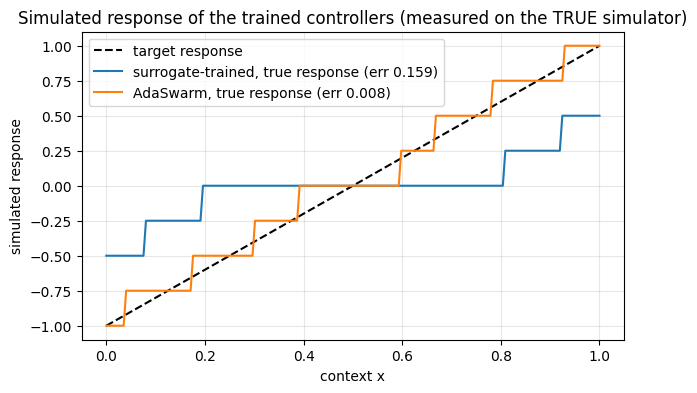

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(x, t, 'k--', label='target response')
plt.plot(x, sim_true(u_surrogate), label=f'surrogate-trained, true response (err {err_surrogate:.3f})')
plt.plot(x, sim_true(u_adaswarm), label=f'AdaSwarm, true response (err {err_adaswarm:.3f})')
plt.title('Simulated response of the trained controllers (measured on the TRUE simulator)')
plt.xlabel('context x'); plt.ylabel('simulated response'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## Takeaways

- The simulator is **non-differentiable**, so standard training must fall back on a **smooth surrogate**
  — which optimises an approximate objective and leaves a systematic error (~0.16 here).
- **AdaSwarm optimises the true simulator directly** (it only evaluates it), reaching the achievable
  staircase levels with ~20× lower true error.
- This is the *derivative-free-in-the-loss* superpower: **train a normal backprop network against a
  black-box you cannot differentiate.**

Real settings with this shape: **physics engines / robotics plant models**, **SPICE circuit
simulators**, **renderers**, **discrete-event / market simulators**, and any pipeline with a
non-differentiable component. See [`docs/use-cases.md`](../docs/use-cases.md).